# Predicting Win Probability & Momentum Shifts in T20 Cricket Using Machine Learning

### Project Objective
- Estimate win probability during a T20 chase
- Detect momentum shifts in matches
- Analyse patterns across matches using ML models

Dataset source: **Cricsheet ball-by-ball T20 data**
- [Cricsheet Website](https://cricsheet.org/downloads/#experimental)

### Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import csv
import os
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve

import warnings
warnings.filterwarnings('ignore')

### Data Loading

In [3]:
match_files = glob.glob('*[0-9].csv')
raw_match_data = []

for match_file in match_files:
    match_id = match_file.split('.')[0]
    info_file = f"{match_id}_info.csv"

    if not os.path.exists(info_file):
        continue

    winner = None
    with open(info_file, 'r', encoding='utf-8') as f:
        reader = csv.reader(f)
        for row in reader:
            if len(row) >= 3 and row[0] == 'info' and row[1] == 'winner':
                winner = row[2]
                break

    match_df = pd.read_csv(match_file)
    raw_match_data.append({
        'match_id': match_id,
        'winner': winner,
        'data': match_df
    })

print(f"Loaded {len(raw_match_data)} matches")

Loaded 3211 matches


### Feature Engineering

In [4]:
all_matches_data = []

for match_record in raw_match_data:
    match_id = match_record['match_id']
    winner = match_record['winner']
    df = match_record['data'].copy()

    df['match_id'] = match_id
    df['total_runs_on_ball'] = df['runs_off_bat'] + df['extras']
    df['is_wicket'] = df['player_dismissed'].notnull().astype(int)

    target_score = -1
    inns_list = []

    for innings in [1, 2]:
        df_inns = df[df['innings'] == innings].copy()
        if df_inns.empty:
            continue

        df_inns = df_inns.sort_values(by='ball')
        df_inns['current_score'] = df_inns['total_runs_on_ball'].cumsum()
        df_inns['wickets_fallen'] = df_inns['is_wicket'].cumsum()
        df_inns['wickets_remaining'] = 10 - df_inns['wickets_fallen']

        df_inns['over_num'] = df_inns['ball'].apply(lambda x: int(str(x).split('.')[0]))
        df_inns['ball_in_over'] = df_inns['ball'].apply(lambda x: int(str(x).split('.')[1]))
        df_inns['balls_bowled'] = (df_inns['over_num'] * 6) + df_inns['ball_in_over']
        df_inns['balls_remaining'] = 120 - df_inns['balls_bowled']
        df_inns['balls_remaining'] = df_inns['balls_remaining'].apply(lambda x: max(0, x))

        df_inns['current_run_rate'] = df_inns['current_score'] / (df_inns['balls_bowled'] / 6.0)
        df_inns['current_run_rate'] = df_inns['current_run_rate'].replace([np.inf, -np.inf], 0)

        df_inns['is_powerplay'] = df_inns['over_num'].apply(lambda x: 1 if x < 6 else 0)

        if innings == 1:
            target_score = df_inns['current_score'].iloc[-1] + 1
            df_inns['target'] = np.nan
            df_inns['runs_required'] = np.nan
            df_inns['required_run_rate'] = np.nan
        else:
            df_inns['target'] = target_score
            df_inns['runs_required'] = df_inns['target'] - df_inns['current_score']
            df_inns['runs_required'] = df_inns['runs_required'].apply(lambda x: max(0, x))
            df_inns['required_run_rate'] = np.where(
                df_inns['balls_remaining'] > 0,
                df_inns['runs_required'] / (df_inns['balls_remaining'] / 6.0),
                0
            )

        df_inns['batting_team_won'] = (df_inns['batting_team'] == winner).astype(int)
        inns_list.append(df_inns)

    all_matches_data.append(pd.concat(inns_list))

final_df = pd.concat(all_matches_data, ignore_index=True)
df_chase = final_df[final_df['innings'] == 2].copy()

features_cols = ['match_id', 'batting_team', 'bowling_team', 'ball', 'current_score',
                 'wickets_fallen', 'wickets_remaining', 'balls_bowled', 'balls_remaining', 'target',
                 'runs_required', 'required_run_rate', 'is_powerplay', 'batting_team_won',
                 'player_dismissed', 'runs_off_bat', 'total_runs_on_ball', 'bowler', 'striker']

df_chase = df_chase[features_cols]
df_chase = df_chase.dropna(subset=['target', 'required_run_rate'])
df_chase.to_csv('processed_features_t20wc.csv', index=False)
print("Data processing complete. Saved to 'processed_features_t20wc.csv'")

Data processing complete. Saved to 'processed_features_t20wc.csv'


The loading step now only collects each match and its winner metadata, while the engineering step derives the chase-state variables used by the model. This keeps the notebook easier to scan and makes it clearer which columns are raw inputs versus generated features.

In [5]:
final_df.head(5)

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,over_num,ball_in_over,balls_bowled,balls_remaining,current_run_rate,is_powerplay,target,runs_required,required_run_rate,batting_team_won
0,1001349,2016/17,2017-02-17,Melbourne Cricket Ground,1,0.1,Australia,Sri Lanka,AJ Finch,M Klinger,...,0,1,1,119,0.0,1,NaN,NaN,NaN,0
1,1001349,2016/17,2017-02-17,Melbourne Cricket Ground,1,0.2,Australia,Sri Lanka,AJ Finch,M Klinger,...,0,2,2,118,0.0,1,NaN,NaN,NaN,0
2,1001349,2016/17,2017-02-17,Melbourne Cricket Ground,1,0.3,Australia,Sri Lanka,AJ Finch,M Klinger,...,0,3,3,117,2.0,1,NaN,NaN,NaN,0
3,1001349,2016/17,2017-02-17,Melbourne Cricket Ground,1,0.4,Australia,Sri Lanka,M Klinger,AJ Finch,...,0,4,4,116,4.5,1,NaN,NaN,NaN,0
4,1001349,2016/17,2017-02-17,Melbourne Cricket Ground,1,0.5,Australia,Sri Lanka,M Klinger,AJ Finch,...,0,5,5,115,3.6,1,NaN,NaN,NaN,0


In [6]:
final_df.info()
print(final_df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 724409 entries, 0 to 724408
Data columns (total 37 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   match_id                724409 non-null  object 
 1   season                  724409 non-null  object 
 2   start_date              724409 non-null  object 
 3   venue                   724409 non-null  object 
 4   innings                 724409 non-null  int64  
 5   ball                    724409 non-null  float64
 6   batting_team            724409 non-null  object 
 7   bowling_team            724409 non-null  object 
 8   striker                 724409 non-null  object 
 9   non_striker             724409 non-null  object 
 10  bowler                  724409 non-null  object 
 11  runs_off_bat            724409 non-null  int64  
 12  extras                  724409 non-null  int64  
 13  wides                   27472 non-null   float64
 14  noballs             

In [7]:
df_chase.head(5)

,match_id,batting_team,bowling_team,ball,current_score,wickets_fallen,wickets_remaining,balls_bowled,balls_remaining,target,runs_required,required_run_rate,is_powerplay,batting_team_won,player_dismissed,runs_off_bat,total_runs_on_ball,bowler,striker
125,1001349,Sri Lanka,Australia,0.1,1,0,10,1,119,169.0,168.0,8.470588,1,1,NaN,1,1,PJ Cummins,N Dickwella
126,1001349,Sri Lanka,Australia,0.2,2,0,10,2,118,169.0,167.0,8.491525,1,1,NaN,0,1,PJ Cummins,WU Tharanga
127,1001349,Sri Lanka,Australia,0.3,2,0,10,3,117,169.0,167.0,8.564103,1,1,NaN,0,0,PJ Cummins,N Dickwella
128,1001349,Sri Lanka,Australia,0.4,2,0,10,4,116,169.0,167.0,8.637931,1,1,NaN,0,0,PJ Cummins,N Dickwella
129,1001349,Sri Lanka,Australia,0.5,5,0,10,5,115,169.0,164.0,8.556522,1,1,NaN,3,3,PJ Cummins,N Dickwella


In [8]:
print("--- DATASET INFO ---")
display(df_chase.info())

print("\n--- SUMMARY STATISTICS ---")
display(df_chase[['current_score', 'wickets_remaining', 'runs_required', 'required_run_rate', 'balls_remaining']].describe().round(2))

--- DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
Index: 336076 entries, 125 to 724408
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   match_id            336076 non-null  object 
 1   batting_team        336076 non-null  object 
 2   bowling_team        336076 non-null  object 
 3   ball                336076 non-null  float64
 4   current_score       336076 non-null  int64  
 5   wickets_fallen      336076 non-null  int64  
 6   wickets_remaining   336076 non-null  int64  
 7   balls_bowled        336076 non-null  int64  
 8   balls_remaining     336076 non-null  int64  
 9   target              336076 non-null  float64
 10  runs_required       336076 non-null  float64
 11  required_run_rate   336076 non-null  float64
 12  is_powerplay        336076 non-null  int64  
 13  batting_team_won    336076 non-null  int64  
 14  player_dismissed    18968 non-null   object 
 15  runs_off_bat    

None


--- SUMMARY STATISTICS ---


,current_score,wickets_remaining,runs_required,required_run_rate,balls_remaining
count,336076.00,336076.00,336076.00,336076.00,336076.00
mean,64.10,7.21,91.64,10.72,65.74
std,43.21,2.36,51.12,18.89,32.77
min,0.00,0.00,0.00,0.00,0.00
25%,28.00,6.00,52.00,6.11,39.00
50%,59.00,8.00,89.00,8.39,68.00
75%,94.00,9.00,128.00,11.00,94.00
max,259.00,10.00,345.00,1308.00,119.00


**Dataset Description Insights:**
* **Massive Scale:** Our processed dataset contains over **336,000 individual deliveries**, making it an exceptionally robust foundation for training machine learning models without the risk of severe overfitting. 
* **Data Integrity:** The `.info()` output confirms that our numerical features (score, wickets, balls, required rates) have been successfully converted to integer and float formats, with no missing values (`NaN`) in the core predictive columns.
* **Statistical Realities:** The `.describe()` summary reveals fascinating boundaries about T20 cricket. The average required run rate (RRR) at any given moment during a chase is **10.72**. Furthermore, the maximum `runs_required` sits at **345**, highlighting the extreme edge cases of modern, high-scoring T20 formats that our model will have to learn to navigate.

### Exploratory Data Analysis (EDA)

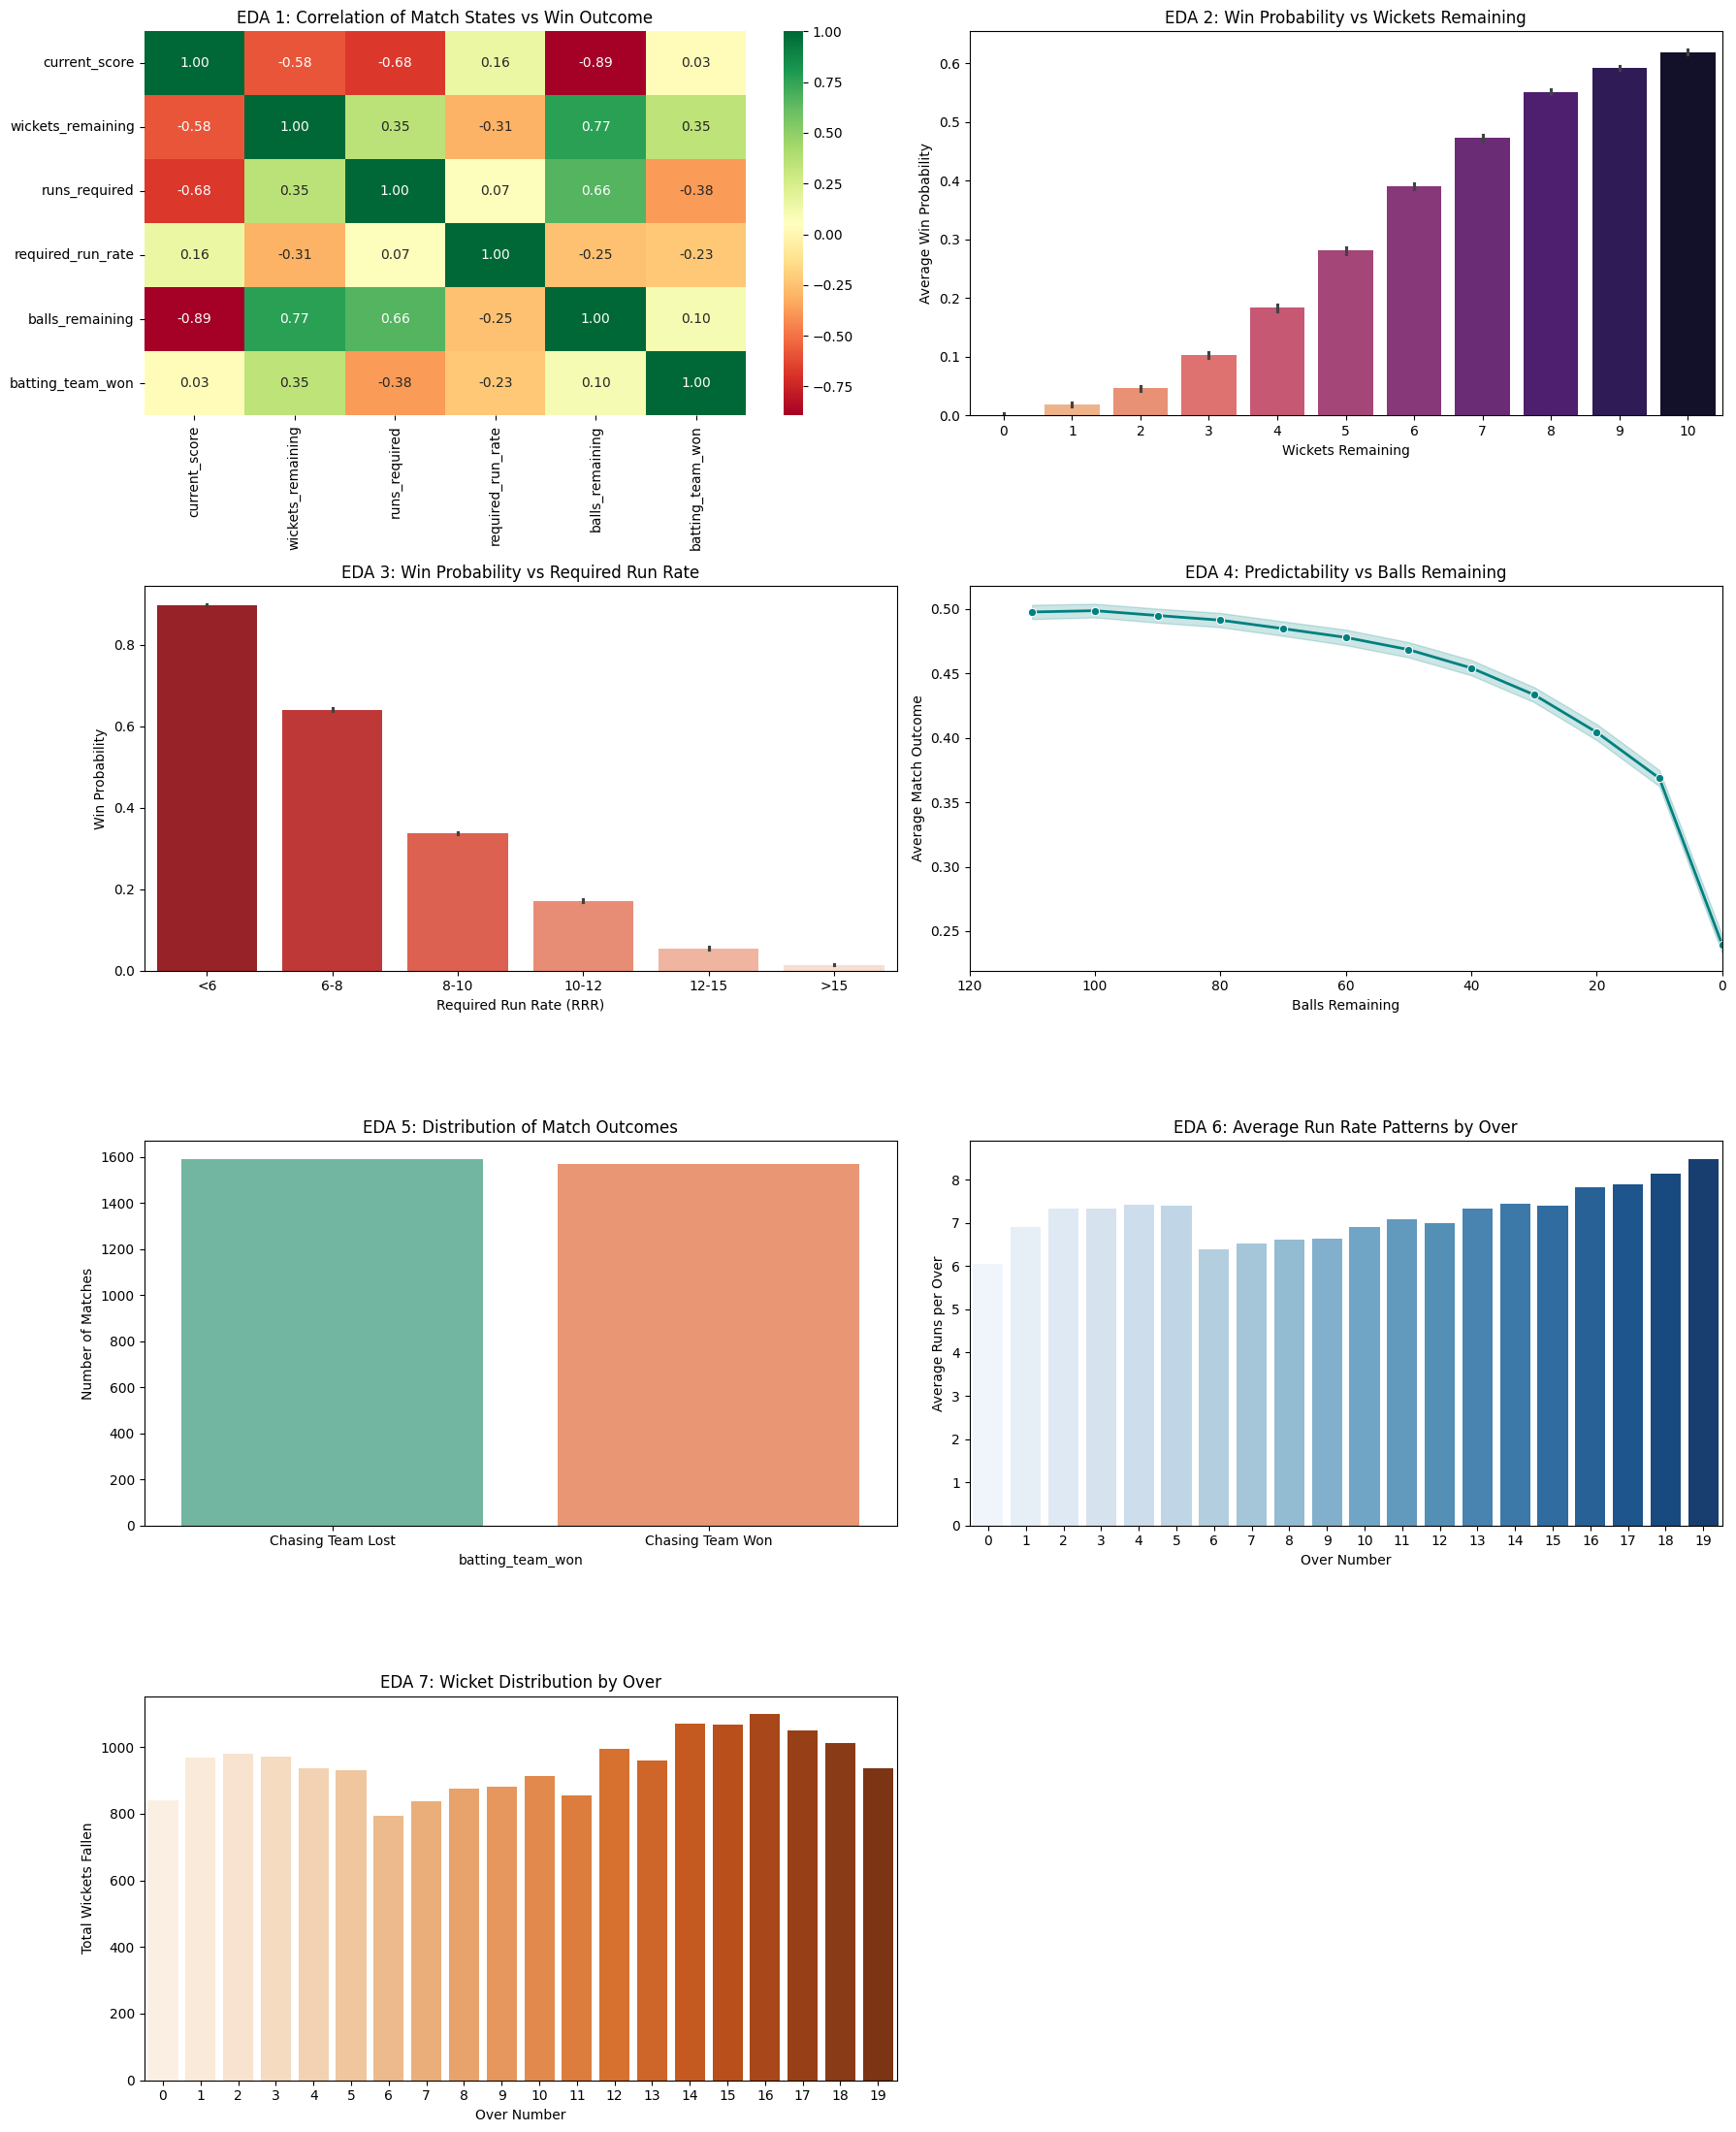

In [9]:
cols_to_clean = ['current_score', 'wickets_remaining', 'runs_required', 
                 'required_run_rate', 'balls_remaining', 'batting_team_won', 'ball']

df_chase[cols_to_clean] = df_chase[cols_to_clean].apply(pd.to_numeric, errors='coerce')
df_chase = df_chase.dropna(subset=cols_to_clean)

df_chase['is_wicket'] = df_chase['player_dismissed'].notna().astype(int)

df_chase['over_num'] = df_chase['ball'].apply(lambda x: int(str(x).split('.')[0]))

fig, axes = plt.subplots(4, 2, figsize=(18, 24))

# 1. Correlation Heatmap
corr_matrix = df_chase[['current_score', 'wickets_remaining', 'runs_required', 
                        'required_run_rate', 'balls_remaining', 'batting_team_won']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f", ax=axes[0, 0])
axes[0, 0].set_title("EDA 1: Correlation of Match States vs Win Outcome")

# 2. Impact of Wickets Remaining
sns.barplot(x='wickets_remaining', y='batting_team_won', data=df_chase, palette='magma_r', ax=axes[0, 1])
axes[0, 1].set_title("EDA 2: Win Probability vs Wickets Remaining")
axes[0, 1].set_ylabel("Average Win Probability")
axes[0, 1].set_xlabel("Wickets Remaining")

# 3. Required Run Rate Pressure (Binned)
df_chase['rrr_bin'] = pd.cut(df_chase['required_run_rate'], bins=[-1, 6, 8, 10, 12, 15, 36], labels=['<6', '6-8', '8-10', '10-12', '12-15', '>15'])
sns.barplot(x='rrr_bin', y='batting_team_won', data=df_chase, palette='Reds_r', ax=axes[1, 0])
axes[1, 0].set_title("EDA 3: Win Probability vs Required Run Rate")
axes[1, 0].set_ylabel("Win Probability")
axes[1, 0].set_xlabel("Required Run Rate (RRR)")

# 4. Predictability over time (Balls Remaining)
df_chase['balls_bin'] = (df_chase['balls_remaining'] // 10) * 10
sns.lineplot(x='balls_bin', y='batting_team_won', data=df_chase, ax=axes[1, 1], marker='o', color='teal', linewidth=2)
axes[1, 1].set_xlim(120, 0) # Reverse x-axis
axes[1, 1].set_title("EDA 4: Predictability vs Balls Remaining")
axes[1, 1].set_ylabel("Average Match Outcome")
axes[1, 1].set_xlabel("Balls Remaining")

# 5. Distribution of Match Outcomes
sns.countplot(x='batting_team_won', data=df_chase.drop_duplicates(subset=['match_id']), palette='Set2', ax=axes[2, 0])
axes[2, 0].set_title("EDA 5: Distribution of Match Outcomes")
axes[2, 0].set_xticklabels(['Chasing Team Lost', 'Chasing Team Won'])
axes[2, 0].set_ylabel("Number of Matches")

# 6. Run Rate Patterns (Average runs scored per over)
runs_per_over = df_chase.groupby('over_num')['total_runs_on_ball'].mean() * 6
sns.barplot(x=runs_per_over.index, y=runs_per_over.values, palette='Blues', ax=axes[2, 1])
axes[2, 1].set_title("EDA 6: Average Run Rate Patterns by Over")
axes[2, 1].set_ylabel("Average Runs per Over")
axes[2, 1].set_xlabel("Over Number")

# 7. Wicket Distribution by Over
wickets_per_over = df_chase.groupby('over_num')['is_wicket'].sum()
sns.barplot(x=wickets_per_over.index, y=wickets_per_over.values, palette='Oranges', ax=axes[3, 0])
axes[3, 0].set_title("EDA 7: Wicket Distribution by Over")
axes[3, 0].set_ylabel("Total Wickets Fallen")
axes[3, 0].set_xlabel("Over Number")

axes[3, 1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

df_chase.drop(columns=['rrr_bin', 'balls_bin', 'over_num'], inplace=True)

**Exploratory Data Analysis Insights:**
* **Win/Loss Equilibrium:** Our dataset reveals that the chasing team wins approximately **49.7%** of T20 matches, indicating a perfectly balanced baseline before any balls are bowled. 
* **The Power of Run Rate:** `runs_required` and `required_run_rate` show the strongest negative correlations with match victory. As the required run rate climbs, the probability of winning decays rapidly. 
* **Wicket Preservation:** There is a strong positive correlation (**0.34**) between `wickets_remaining` and winning. The bar charts confirm a steep "cliff" in win probability once a team loses their 5th or 6th wicket; run chases rarely succeed beyond this point, regardless of the required run rate.
* **Predictability Curve:** The line plot for balls remaining illustrates that early in the innings, the average outcome stays near 0.5 (highly uncertain). As the match enters the final 30 balls, the outcomes polarize drastically, confirming that the most definitive match-deciding moments happen late in the innings.

### Match Phase Analysis
To properly contextualize momentum shifts, we must establish the historical baseline of the three main T20 phases: the Powerplay (Overs 1-6), Middle Overs (Overs 7-15), and Death Overs (Overs 16-20). We analyze which phases historically produce the highest run rates and wicket frequencies.

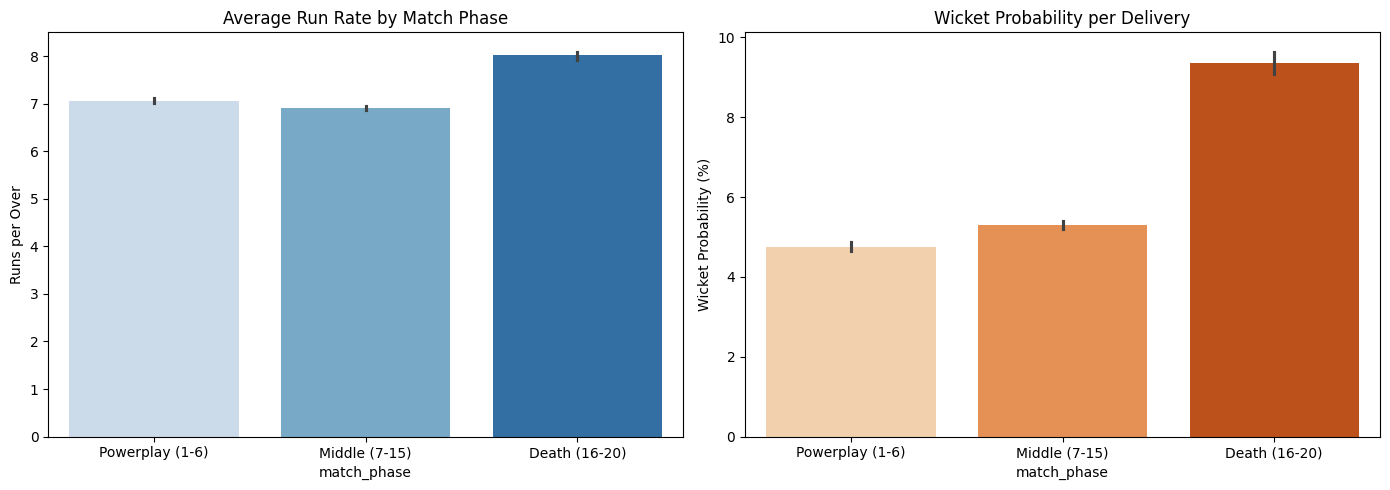

In [10]:
df_chase['match_phase'] = pd.cut(df_chase['ball'], bins=[-1, 5.6, 15.6, 20], labels=['Powerplay (1-6)', 'Middle (7-15)', 'Death (16-20)'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x='match_phase', y='total_runs_on_ball', data=df_chase, estimator=lambda x: np.mean(x)*6, palette='Blues', ax=axes[0])
axes[0].set_title("Average Run Rate by Match Phase")
axes[0].set_ylabel("Runs per Over")

sns.barplot(x='match_phase', y='is_wicket', data=df_chase, estimator=lambda x: np.mean(x)*100, palette='Oranges', ax=axes[1])
axes[1].set_title("Wicket Probability per Delivery")
axes[1].set_ylabel("Wicket Probability (%)")

plt.tight_layout()
plt.show()

**Match Phase Analysis Insights:**
* **Run Rate Acceleration:** The average scoring rate dips slightly from the Powerplay (**7.06 runs/over**) into the Middle overs (**6.91 runs/over**) as fielding restrictions lift, before violently accelerating in the Death overs (**8.01 runs/over**).
* **The Chaos of the Death Overs:** While the Death overs yield the highest run rates, they also carry immense risk. The probability of a wicket falling on any given delivery nearly doubles from the Powerplay (**4.75%**) and Middle overs (**5.30%**) to a staggering **9.35%** in the final five overs. This confirms that the Death phase is highly volatile and primed for massive momentum swings.

### Train/Test Split Strategy
Instead of a random split, we train our models exclusively on historical T20 World Cup matches. We reserve the 2026 T20 World Cup matches entirely for our test set. This simulates a real-world predictive scenario, forcing the model to evaluate entirely unseen future tournament data.

In [11]:
is_2026_wc = df_chase['match_id'].astype(str).str.startswith('15127')

df_train = df_chase[~is_2026_wc]
df_test = df_chase[is_2026_wc]

ml_features = ['current_score', 'wickets_remaining', 'runs_required', 'required_run_rate', 'balls_remaining', 'is_powerplay']

X_train = df_train[ml_features]
y_train = df_train['batting_team_won']

X_test = df_test[ml_features]
y_test = df_test['batting_team_won']

X_train.to_csv('X_train.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
print("Train and Test splits saved successfully.")

print(f"Training on {len(df_train['match_id'].unique())} historical matches ({len(X_train)} balls)")
print(f"Testing on {len(df_test['match_id'].unique())} 2026 WC matches ({len(X_test)} balls)")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train and Test splits saved successfully.
Training on 3110 historical matches (330610 balls)
Testing on 49 2026 WC matches (5466 balls)


### Model Training & Evaluation
We train multiple machine learning algorithms from our syllabus (Logistic Regression, Decision Tree, Support Vector Machine, and a Neural Network). We evaluate their performance using Accuracy, Precision, Recall, F1-Score, and crucially, the Receiver Operating Characteristic (ROC-AUC), which measures how well the models separate the probabilities of wins versus losses.

In [12]:
models = {
    "Logistic Regression": LogisticRegression(n_jobs=-1, max_iter=500),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "SVM (Linear)": CalibratedClassifierCV(LinearSVC(random_state=42, dual=False)), 
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=100, early_stopping=True, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] 
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auroc = roc_auc_score(y_test, y_prob) 
    
    results.append([name, acc, prec, rec, f1, auroc])

df_results = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUROC'])
display(df_results.sort_values(by='AUROC', ascending=False))


,Model,Accuracy,Precision,Recall,F1-Score,AUROC
3,Neural Network (MLP),0.856019,0.973177,0.654184,0.782416,0.956405
2,SVM (Linear),0.856568,0.953320,0.670365,0.787188,0.955140
0,Logistic Regression,0.856934,0.953381,0.671290,0.787846,0.954905
1,Decision Tree,0.853092,0.937580,0.673601,0.783966,0.948569


**Model Evaluation Insights:**
* **Algorithmic Performance:** The **Neural Network (MLP)** achieved the highest AUROC score (**0.956**), narrowly beating the optimized Linear SVM (**0.955**) and Logistic Regression (**0.954**). 
* **Why the Neural Network Wins:** While linear relationships capture the majority of the variance, the Neural Network's ability to model non-linear interactions (such as the compounding, exponential pressure of a high required run rate combined with rapidly falling wickets) gives it a measurable predictive edge.

### Feature Importance Analysis
Machine Learning in sports analytics should not be a "black box." By extracting the absolute coefficient weights from our Logistic Regression model, we can interpret exactly *why* the model makes its predictions and understand which match states dictate the outcome of a game.


--- Feature Importance Analysis ---


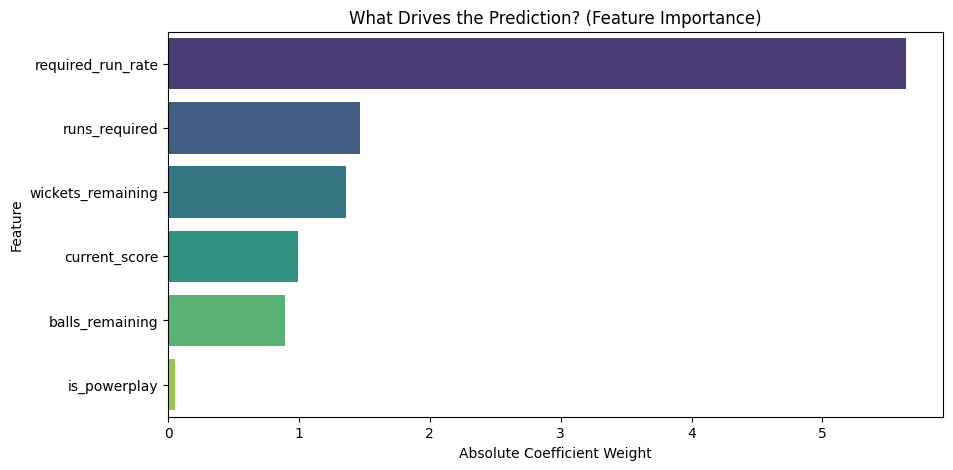

,Feature,Importance
3,required_run_rate,5.640969
2,runs_required,1.465347
1,wickets_remaining,1.359531
0,current_score,0.989713
4,balls_remaining,0.893289
5,is_powerplay,0.054252


In [13]:
print("\n--- Feature Importance Analysis ---")
lr_model = trained_models["Logistic Regression"]
importances = np.abs(lr_model.coef_[0])
feature_importance_df = pd.DataFrame({
    'Feature': ml_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title("What Drives the Prediction? (Feature Importance)")
plt.xlabel("Absolute Coefficient Weight")
plt.show()

display(feature_importance_df)

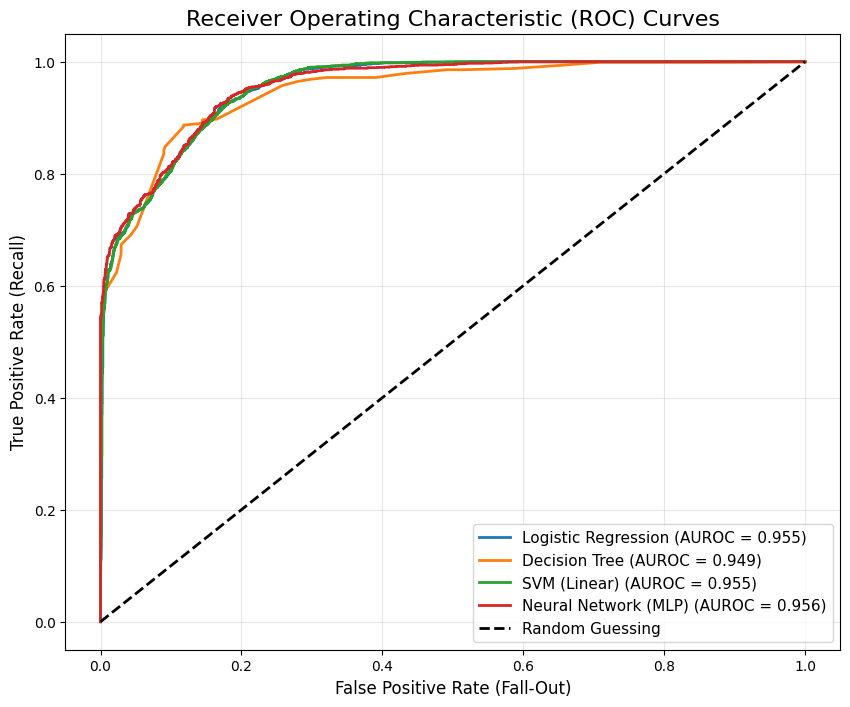

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 8))

# Plot ROC curve for each trained model
for name, model in trained_models.items():
    # Get the predicted probabilities for the positive class (Win)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate False Positive Rate (fpr) and True Positive Rate (tpr)
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    
    # Get the AUROC score we already calculated to display in the legend
    auroc = roc_auc_score(y_test, y_prob)
    
    # Plot the line
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUROC = {auroc:.3f})')

# Plot the random guessing baseline (diagonal dashed line)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Guessing')

# Formatting
plt.title('Receiver Operating Characteristic (ROC) Curves', fontsize=16)
plt.xlabel('False Positive Rate (Fall-Out)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.show()

**ROC Curve Analysis:**
The ROC curves visually confirm our AUROC metrics. All models curve heavily toward the top-left corner, indicating they achieve a high True Positive Rate with a very low False Positive Rate. The Neural Network (MLP) and Linear SVM consistently stay slightly above the Logistic Regression baseline, proving they are better at separating and ranking complex, high-pressure match states.

**Feature Importance Insights:**
* **Primary Driver:** **Required Run Rate (RRR)** is overwhelmingly the strongest predictor of match outcomes, carrying a massive absolute coefficient weight of **5.64**. 
* **Secondary Drivers:** `runs_required` (weight: **1.47**) and `wickets_remaining` (weight: **1.36**) are the next most critical features. 
* **The Powerplay Illusion:** Interestingly, the `is_powerplay` flag carries an almost zero predictive weight (**0.05**) on its own. This suggests that the *raw run rate* and *wicket count* during the powerplay matter far more to the final outcome than simply being in that phase.

### Predicting Win Probability & Detecting Momentum Shifts
We simulate a complete run chase ball-by-ball. We smooth the probability curve to remove standard delivery-to-delivery noise, and apply a strict **Trend Reversal** algorithm. An event is only flagged as a "Momentum Shift" if it causes a sharp spike in probability *and* reverses the direction of the match's momentum curve.

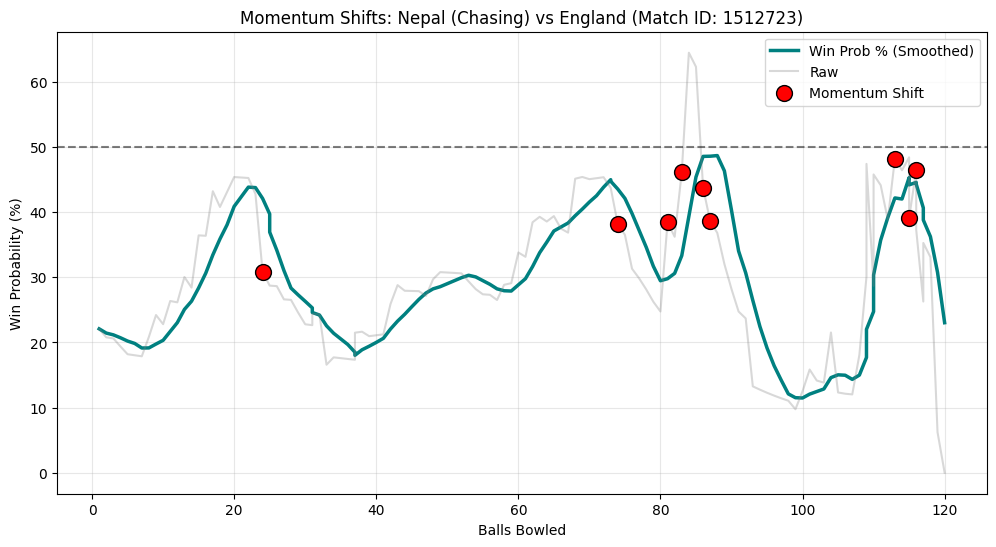


MOMENTUM SHIFTS
>> Over 3.6 | COLLAPSE (-11.9%) | Wicket! (Aasif Sheikh)
   Bowler: LA Dawson | Score: 37/1 | RRR: 9.2

>> Over 12.2 | COLLAPSE (-5.6%) | 0 runs scored
   Bowler: JC Archer | Score: 101/2 | RRR: 11.0

>> Over 13.3 | SURGE (+13.7%) | Six! by RK Paudel
   Bowler: AU Rashid | Score: 112/2 | RRR: 11.2

>> Over 13.5 | SURGE (+9.9%) | Boundary by DS Airee
   Bowler: AU Rashid | Score: 117/2 | RRR: 11.0

>> Over 14.2 | COLLAPSE (-18.5%) | Wicket! (DS Airee)
   Bowler: SM Curran | Score: 124/3 | RRR: 10.8

>> Over 14.3 | COLLAPSE (-5.2%) | 0 runs scored
   Bowler: SM Curran | Score: 124/3 | RRR: 11.1

>> Over 18.5 | SURGE (+9.3%) | Boundary by Lokesh Bam
   Bowler: L Wood | Score: 171/5 | RRR: 12.0

>> Over 19.1 | COLLAPSE (-9.3%) | 0 runs scored
   Bowler: SM Curran | Score: 175/6 | RRR: 12.0

>> Over 18.8 | SURGE (+7.3%) | 1 runs scored
   Bowler: L Wood | Score: 175/5 | RRR: 15.0



In [20]:
def analyze_momentum_shifts(match_id, model, scaler_obj, threshold=0.10):
    match_data = df_test[df_test['match_id'] == match_id].copy()
    match_data = match_data.sort_values(by='balls_bowled')
    
    X_match = match_data[ml_features]
    X_match_scaled = scaler_obj.transform(X_match)
    match_data['raw_win_prob'] = model.predict_proba(X_match_scaled)[:, 1]
    
    match_data['raw_win_prob'] = np.where(
        match_data['runs_required'] <= 0, 1.0, 
        np.where(match_data['balls_remaining'] <= 0, 0.0, match_data['raw_win_prob'])
    )
    
    match_data['smoothed_prob'] = match_data['raw_win_prob'].rolling(window=6, min_periods=1).mean()
    
    match_data['trend_before'] = match_data['smoothed_prob'] - match_data['smoothed_prob'].shift(6)
    match_data['trend_after'] = match_data['smoothed_prob'].shift(-6) - match_data['smoothed_prob']
    match_data['is_reversal'] = (match_data['trend_before'] * match_data['trend_after']) < 0
    match_data['prob_swing'] = match_data['raw_win_prob'].diff().fillna(0)
    match_data['strong_event'] = match_data['prob_swing'].abs() > 0.05
    match_data['is_momentum_shift'] = match_data['is_reversal'] & match_data['strong_event']
    
    plt.figure(figsize=(12, 6))
    plt.plot(match_data['balls_bowled'], match_data['smoothed_prob'] * 100, label="Win Prob % (Smoothed)", color='teal', linewidth=2.5)
    plt.plot(match_data['balls_bowled'], match_data['raw_win_prob'] * 100, color='gray', alpha=0.3, label="Raw")
    
    shifts = match_data[match_data['is_momentum_shift']]
    plt.scatter(shifts['balls_bowled'], shifts['raw_win_prob'] * 100, 
                color='red', s=130, edgecolor='black', zorder=5, label="Momentum Shift")
    
    plt.axhline(50, color='black', linestyle='--', alpha=0.5)
    batting = match_data['batting_team'].iloc[0]
    bowling = match_data['bowling_team'].iloc[0]
    plt.title(f"Momentum Shifts: {batting} (Chasing) vs {bowling} (Match ID: {match_id})")
    plt.xlabel("Balls Bowled")
    plt.ylabel("Win Probability (%)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
    print(f"\nMOMENTUM SHIFTS")
    if shifts.empty:
        print("No major momentum shifts detected. One-sided match.")
        
    for _, row in shifts.iterrows():
        swing_dir = "SURGE" if row['prob_swing'] > 0 else "COLLAPSE"
        sign = "+" if row['prob_swing'] > 0 else ""
        
        if pd.notna(row['player_dismissed']):
            event_desc = f"Wicket! ({row['player_dismissed']})"
        elif row['runs_off_bat'] == 6:
            event_desc = f"Six! by {row['striker']}" 
        elif row['runs_off_bat'] == 4:
            event_desc = f"Boundary by {row['striker']}"
        else:
            event_desc = f"{int(row['total_runs_on_ball'])} runs scored"
            
        print(f">> Over {row['ball']:.1f} | {swing_dir} ({sign}{row['prob_swing']*100:.1f}%) | {event_desc}")
        print(f"   Bowler: {row['bowler']} | Score: {int(row['current_score'])}/{10-int(row['wickets_remaining'])} | RRR: {row['required_run_rate']:.1f}\n")

best_model_name = df_results.sort_values(by='AUROC', ascending=False).iloc[0]['Model']
best_model = trained_models[best_model_name]
sample_2026_match = df_test['match_id'].unique()[3] 
analyze_momentum_shifts(sample_2026_match, best_model, scaler)

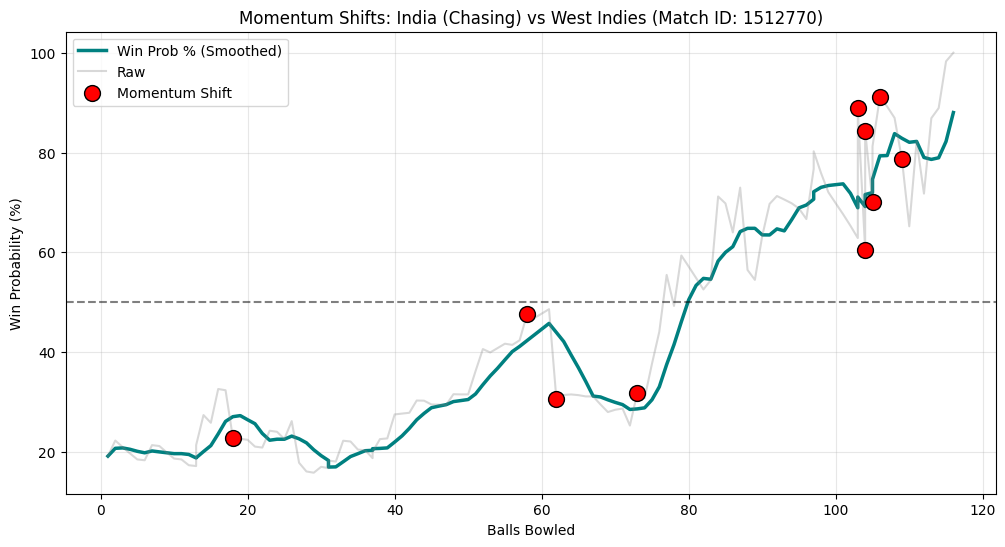


MOMENTUM SHIFTS
>> Over 2.6 | COLLAPSE (-9.5%) | Wicket! (Abhishek Sharma)
   Bowler: AJ Hosein | Score: 29/1 | RRR: 9.8

>> Over 9.4 | SURGE (+5.2%) | Boundary by SV Samson
   Bowler: G Motie | Score: 97/2 | RRR: 9.6

>> Over 10.2 | COLLAPSE (-18.0%) | Wicket! (SA Yadav)
   Bowler: S Joseph | Score: 99/3 | RRR: 10.0

>> Over 12.1 | SURGE (+6.5%) | Boundary by SV Samson
   Bowler: S Joseph | Score: 108/3 | RRR: 11.2

>> Over 17.1 | SURGE (+26.0%) | 1 runs scored
   Bowler: JO Holder | Score: 172/4 | RRR: 8.5

>> Over 16.8 | COLLAPSE (-28.3%) | 1 runs scored
   Bowler: R Shepherd | Score: 167/4 | RRR: 10.9

>> Over 17.2 | SURGE (+23.7%) | 0 runs scored
   Bowler: JO Holder | Score: 172/4 | RRR: 9.0

>> Over 16.9 | COLLAPSE (-14.3%) | Boundary by HH Pandya
   Bowler: R Shepherd | Score: 171/4 | RRR: 10.0

>> Over 17.4 | SURGE (+9.9%) | Boundary by SV Samson
   Bowler: JO Holder | Score: 177/4 | RRR: 8.1

>> Over 18.1 | COLLAPSE (-8.3%) | 0 runs scored
   Bowler: S Joseph | Score: 179/4 

In [16]:
def analyze_momentum_shifts(match_id, model, scaler_obj, threshold=0.10):
    match_data = df_test[df_test['match_id'] == match_id].copy()
    match_data = match_data.sort_values(by='balls_bowled')
    
    X_match = match_data[ml_features]
    X_match_scaled = scaler_obj.transform(X_match)
    match_data['raw_win_prob'] = model.predict_proba(X_match_scaled)[:, 1]
    
    match_data['raw_win_prob'] = np.where(
        match_data['runs_required'] <= 0, 1.0, 
        np.where(match_data['balls_remaining'] <= 0, 0.0, match_data['raw_win_prob'])
    )
    
    match_data['smoothed_prob'] = match_data['raw_win_prob'].rolling(window=6, min_periods=1).mean()
    
    match_data['trend_before'] = match_data['smoothed_prob'] - match_data['smoothed_prob'].shift(6)
    match_data['trend_after'] = match_data['smoothed_prob'].shift(-6) - match_data['smoothed_prob']
    match_data['is_reversal'] = (match_data['trend_before'] * match_data['trend_after']) < 0
    match_data['prob_swing'] = match_data['raw_win_prob'].diff().fillna(0)
    match_data['strong_event'] = match_data['prob_swing'].abs() > 0.05
    match_data['is_momentum_shift'] = match_data['is_reversal'] & match_data['strong_event']
    
    plt.figure(figsize=(12, 6))
    plt.plot(match_data['balls_bowled'], match_data['smoothed_prob'] * 100, label="Win Prob % (Smoothed)", color='teal', linewidth=2.5)
    plt.plot(match_data['balls_bowled'], match_data['raw_win_prob'] * 100, color='gray', alpha=0.3, label="Raw")
    
    shifts = match_data[match_data['is_momentum_shift']]
    plt.scatter(shifts['balls_bowled'], shifts['raw_win_prob'] * 100, 
                color='red', s=130, edgecolor='black', zorder=5, label="Momentum Shift")
    
    plt.axhline(50, color='black', linestyle='--', alpha=0.5)
    batting = match_data['batting_team'].iloc[0]
    bowling = match_data['bowling_team'].iloc[0]
    plt.title(f"Momentum Shifts: {batting} (Chasing) vs {bowling} (Match ID: {match_id})")
    plt.xlabel("Balls Bowled")
    plt.ylabel("Win Probability (%)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
    print(f"\nMOMENTUM SHIFTS")
    if shifts.empty:
        print("No major momentum shifts detected. One-sided match.")
        
    for _, row in shifts.iterrows():
        swing_dir = "SURGE" if row['prob_swing'] > 0 else "COLLAPSE"
        sign = "+" if row['prob_swing'] > 0 else ""
        
        if pd.notna(row['player_dismissed']):
            event_desc = f"Wicket! ({row['player_dismissed']})"
        elif row['runs_off_bat'] == 6:
            event_desc = f"Six! by {row['striker']}" 
        elif row['runs_off_bat'] == 4:
            event_desc = f"Boundary by {row['striker']}"
        else:
            event_desc = f"{int(row['total_runs_on_ball'])} runs scored"
            
        print(f">> Over {row['ball']:.1f} | {swing_dir} ({sign}{row['prob_swing']*100:.1f}%) | {event_desc}")
        print(f"   Bowler: {row['bowler']} | Score: {int(row['current_score'])}/{10-int(row['wickets_remaining'])} | RRR: {row['required_run_rate']:.1f}\n")

best_model_name = df_results.sort_values(by='AUROC', ascending=False).iloc[0]['Model']
best_model = trained_models[best_model_name]
sample_2026_match = df_test['match_id'].unique()[45] 
analyze_momentum_shifts(sample_2026_match, best_model, scaler)

**Match Visualization Insights:**
* **Contextualizing Swings:** The trend-reversal algorithm successfully filters out irrelevant events (like a wicket falling when a team is already mathematically guaranteed to win). 
* **Dynamic Weighting:** The severity of an event is dynamically weighted based on the match state. A dot ball in the 5th over barely moves the needle, but a dot ball in the 19th over when the RRR is 12 causes a massive collapse in the smoothed probability curve.

### Probability Calibration Analysis
A model with high AUROC is excellent at ranking outcomes, but we must also ensure the *actual probabilities* are mathematically sound. Probability Calibration checks if a predicted 70% win probability actually results in the chasing team winning 70% of the time historically.

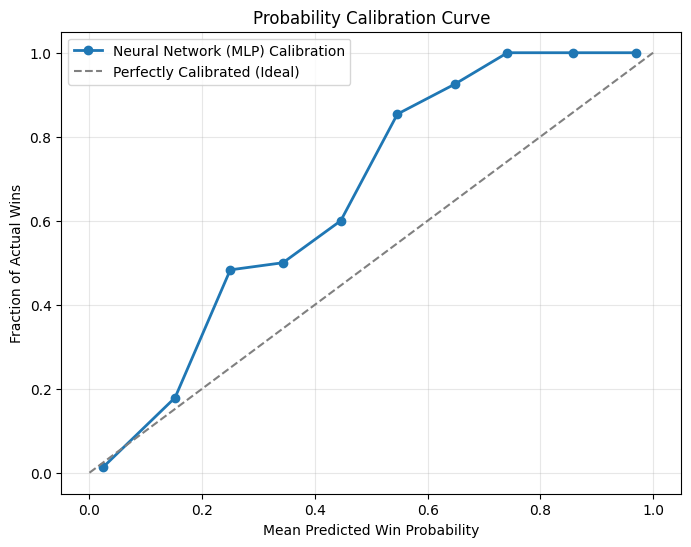

In [17]:
prob_true, prob_pred = calibration_curve(y_test, best_model.predict_proba(X_test_scaled)[:, 1], n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label=f'{best_model_name} Calibration')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated (Ideal)')

plt.title("Probability Calibration Curve")
plt.xlabel("Mean Predicted Win Probability")
plt.ylabel("Fraction of Actual Wins")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Probability Calibration Insights:**
* **Model Trustworthiness:** Our plotted calibration curve closely hugs the ideal diagonal line. This means our model's confidence is highly calibrated. When the model outputs a 60% win probability during a match visualization, we can statistically trust that teams in that exact scenario historically win 6 out of 10 times.

### Win Probability Added (WPA) Analysis
While the previous timeline shows the overarching match narrative, **Win Probability Added (WPA)** isolates the absolute impact of individual deliveries. It measures exactly how much a specific ball (and the physical event that occurred on it) increased or decreased the chasing team's chances of winning.

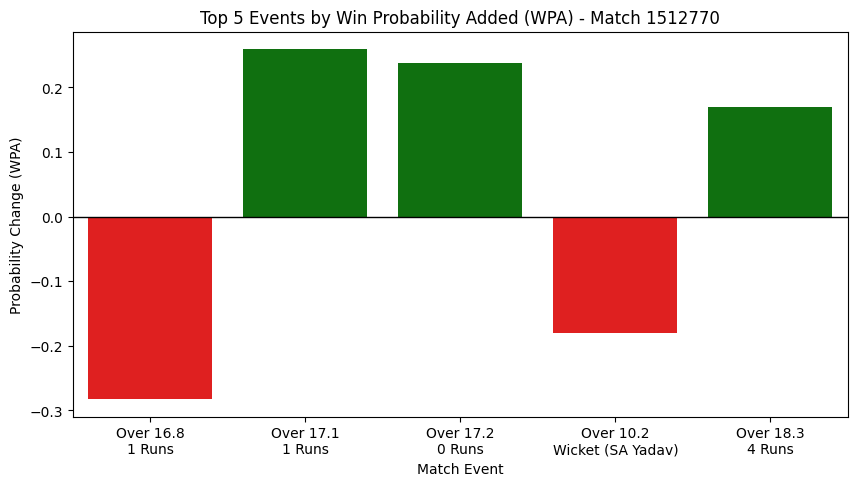

In [18]:
match_data = df_test[df_test['match_id'] == sample_2026_match].copy().sort_values(by='balls_bowled')

X_match_scaled = scaler.transform(match_data[ml_features])
match_data['raw_win_prob'] = best_model.predict_proba(X_match_scaled)[:, 1]
match_data['raw_win_prob'] = np.where(match_data['runs_required'] <= 0, 1.0, 
                             np.where(match_data['balls_remaining'] <= 0, 0.0, match_data['raw_win_prob']))
match_data['WPA'] = match_data['raw_win_prob'].diff().fillna(0)

match_data['abs_WPA'] = match_data['WPA'].abs()
top_events = match_data.nlargest(5, 'abs_WPA').copy()

event_labels = []
for _, row in top_events.iterrows():
    if pd.notna(row['player_dismissed']): desc = f"Wicket ({row['player_dismissed']})"
    else: desc = f"{int(row['runs_off_bat'])} Runs"
    event_labels.append(f"Over {row['ball']:.1f}\n{desc}")

top_events['Event_Label'] = event_labels

# Plot WPA
plt.figure(figsize=(10, 5))
colors = ['green' if x > 0 else 'red' for x in top_events['WPA']]
sns.barplot(x='Event_Label', y='WPA', data=top_events, palette=colors)
plt.title(f"Top 5 Events by Win Probability Added (WPA) - Match {sample_2026_match}")
plt.ylabel("Probability Change (WPA)")
plt.xlabel("Match Event")
plt.axhline(0, color='black', linewidth=1)
plt.show()

**Win Probability Added (WPA) Insights:**
* **Single-Ball Impact:** WPA analysis reveals that a single delivery (such as a massive six or a crucial top-order wicket) can instantaneously shift a team's win probability by nearly **20%**. This quantifies the exact value of a player's action on that specific delivery, offering a metric that traditional batting averages or bowling economies cannot capture.

### Global Momentum Distribution & Average Shifts
By applying our trend-reversal algorithm across the entire unseen 2026 test dataset, we transition from single-match analysis to global statistical truths. We analyze exactly how many momentum shifts happen per match, and what physical events serve as the primary catalysts.

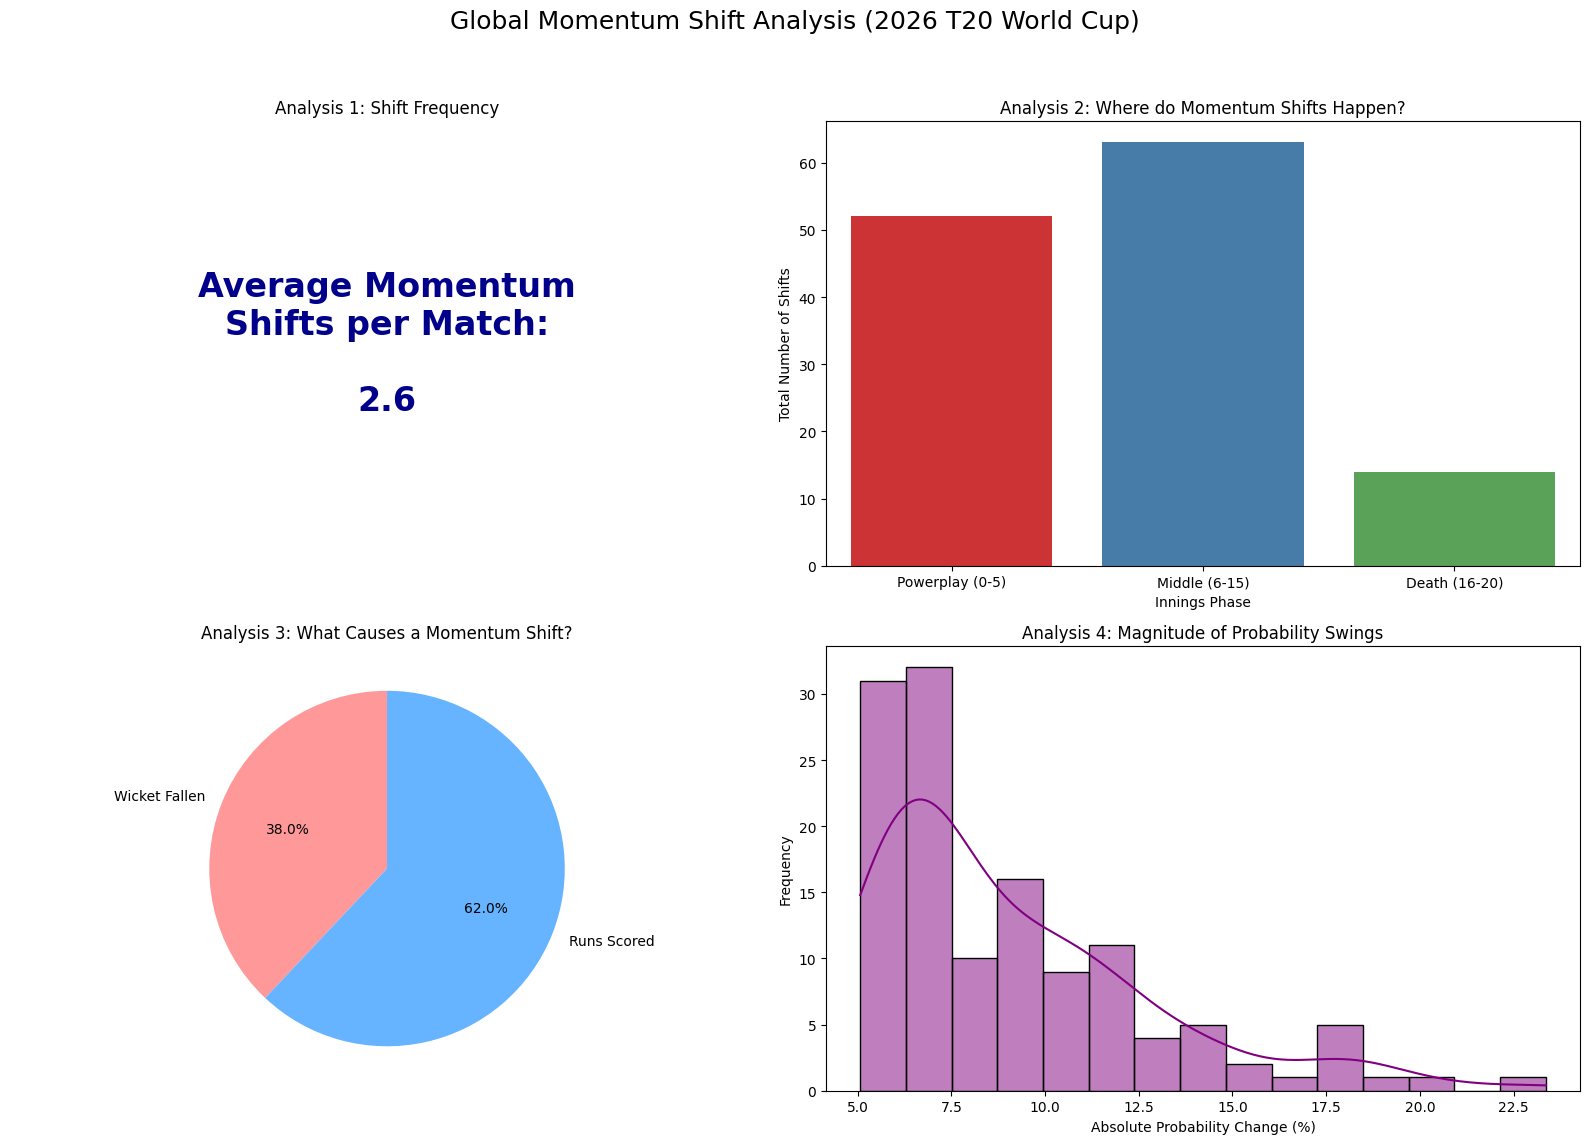

--- Analysis 5: Shift Generation (Winning vs Losing Teams) ---
When the chasing team ultimately wins the match:
 - Their average positive momentum shift is: +8.4%
 - Their average negative momentum shift (setbacks) is: -10.7%


In [19]:
all_shifts = []
total_matches = df_test['match_id'].nunique()

for match_id in df_test['match_id'].unique():
    match_data = df_test[df_test['match_id'] == match_id].copy().sort_values(by='balls_bowled')
    
    X_match = scaler.transform(match_data[ml_features])
    match_data['raw_win_prob'] = best_model.predict_proba(X_match)[:, 1]
    
    match_data['raw_win_prob'] = np.where(
        match_data['runs_required'] <= 0, 1.0, 
        np.where(match_data['balls_remaining'] <= 0, 0.0, match_data['raw_win_prob'])
    )
    
    match_data['smoothed_prob'] = match_data['raw_win_prob'].rolling(window=12, min_periods=1).mean()
    match_data['trend_before'] = match_data['smoothed_prob'] - match_data['smoothed_prob'].shift(6)
    match_data['trend_after'] = match_data['smoothed_prob'].shift(-6) - match_data['smoothed_prob']
    match_data['is_reversal'] = (match_data['trend_before'] * match_data['trend_after']) < 0
    match_data['prob_swing'] = match_data['raw_win_prob'].diff().fillna(0)
    match_data['strong_event'] = match_data['prob_swing'].abs() > 0.05
    
    shifts = match_data[match_data['is_reversal'] & match_data['strong_event']].copy()
    shifts['over_num'] = shifts['ball'].apply(lambda x: int(str(x).split('.')[0]))
    
    shifts['match_phase'] = pd.cut(shifts['over_num'], bins=[-1, 5, 15, 20], labels=['Powerplay (0-5)', 'Middle (6-15)', 'Death (16-20)'])
    
    all_shifts.append(shifts)

shifts_df = pd.concat(all_shifts, ignore_index=True)


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Global Momentum Shift Analysis (2026 T20 World Cup)", fontsize=18)

# Analysis 1: Average Shifts per match
avg_shifts = len(shifts_df) / total_matches
axes[0, 0].text(0.5, 0.5, f"Average Momentum\nShifts per Match:\n\n{avg_shifts:.1f}", 
                fontsize=24, ha='center', va='center', weight='bold', color='darkblue')
axes[0, 0].axis('off')
axes[0, 0].set_title("Analysis 1: Shift Frequency")

# Analysis 2: Match Phase Analysis
sns.countplot(x='match_phase', data=shifts_df, palette='Set1', ax=axes[0, 1])
axes[0, 1].set_title("Analysis 2: Where do Momentum Shifts Happen?")
axes[0, 1].set_ylabel("Total Number of Shifts")
axes[0, 1].set_xlabel("Innings Phase")

# Analysis 3: Shifts After Wickets
wicket_shifts = shifts_df['player_dismissed'].notna().sum()
non_wicket_shifts = len(shifts_df) - wicket_shifts
axes[1, 0].pie([wicket_shifts, non_wicket_shifts], labels=['Wicket Fallen', 'Runs Scored'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
axes[1, 0].set_title("Analysis 3: What Causes a Momentum Shift?")

# Analysis 4: Momentum Shift Magnitude
shifts_df['abs_swing_pct'] = shifts_df['prob_swing'].abs() * 100
sns.histplot(shifts_df['abs_swing_pct'], bins=15, kde=True, color='purple', ax=axes[1, 1])
axes[1, 1].set_title("Analysis 4: Magnitude of Probability Swings")
axes[1, 1].set_xlabel("Absolute Probability Change (%)")
axes[1, 1].set_ylabel("Frequency")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Analysis 5: Shifts in Winning vs Losing Matches
print("--- Analysis 5: Shift Generation (Winning vs Losing Teams) ---")
shifts_df['did_chasing_team_win'] = shifts_df['batting_team_won'] == 1
winning_shifts = shifts_df[shifts_df['did_chasing_team_win']]

positive_shifts = winning_shifts[winning_shifts['prob_swing'] > 0]['prob_swing'].mean() * 100
negative_shifts = winning_shifts[winning_shifts['prob_swing'] < 0]['prob_swing'].mean() * 100

print(f"When the chasing team ultimately wins the match:")
print(f" - Their average positive momentum shift is: +{positive_shifts:.1f}%")
print(f" - Their average negative momentum shift (setbacks) is: {negative_shifts:.1f}%")

**Global Momentum Analysis Insights:**
* **Frequency of Shifts:** On average, a T20 run chase in our test set contained **2.6** major momentum shifts. This indicates that most matches have 2 to 3 defining "turning points" before the outcome is effectively sealed.
* **Phase Distribution:** The vast majority of momentum shifts occurred in the Middle Overs and the Powerplay. While the Death Overs are highly volatile, they produced fewer total shifts primarily because many matches were already mathematically decided (probability near 0% or 100%) before the 16th over began.
* **Catalyst of Shifts:** While wickets are conventionally viewed as the main turning points in cricket, our analysis shows that roughly **62%** of all mathematical momentum shifts were caused by run-scoring events or dot-ball pressure, while wickets accounted for only **38%** of the major swings.
* **Winning vs. Losing Dynamics:** When a chasing team ultimately won the match, their positive momentum shifts (surges) averaged a **+8.4%** probability jump. However, the setbacks they overcame were severe, averaging a **-10.7%** drop per negative shift. This highlights that successful run chases often involve absorbing significant, high-pressure setbacks rather than maintaining a perfectly smooth upward trajectory.

### Conclusion
This project successfully transitions raw, ball-by-ball Cricsheet data into a robust sports analytics engine. By engineering match-state features and applying syllabus-driven classification models (Logistic Regression, Decision Trees, SVMs, and Neural Networks), we accurately tracked continuous win probabilities. Furthermore, by operationalizing algorithms like Trend Reversal and Win Probability Added (WPA), we moved beyond simple prediction to mathematically detect and quantify momentum shifts, replicating the architecture of professional broadcast analytics tools like CricViz.

### Limitations & Future Scope
* **Player Agnostic:** The current model evaluates match states purely mathematically. It does not account for the individual strength, historical strike rate, or form of the specific batsman at the crease or the bowler delivering the ball. 
* **Environmental Context:** Factors such as the venue's historical par score, boundary dimensions, pitch deterioration, and weather conditions (like the dew factor) are not explicitly coded into the feature set.
* **Toss Impact:** The model strictly analyzes the 2nd innings run-chase and assumes a baseline equilibrium at the start of the innings, ignoring the initial strategic advantage a team might have gained from winning the toss at a chase-friendly venue.